In [7]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


In [8]:
import pandas as pd

df = pd.read_csv("../data/17_열처리.csv")

import matplotlib.pyplot as plt

실습6. 선그래프 자유변형
한 설비의 여러 센서를 한 그래프에 종합

목표
한 설비의 여러 센서를 한 그래프에 종합해 그리기

단계
· C호기의 온도·진동·소음을 한 그래프에 겹쳐 그리기

· 단위가 다른 진동은 배수를 곱해 눈에 보이게 보정

· 제목·축 이름·범례로 완성하고 함께 움직이는지 관찰

예상 결과
C호기 온도·진동·소음이 함께 상승하는 종합 그래프

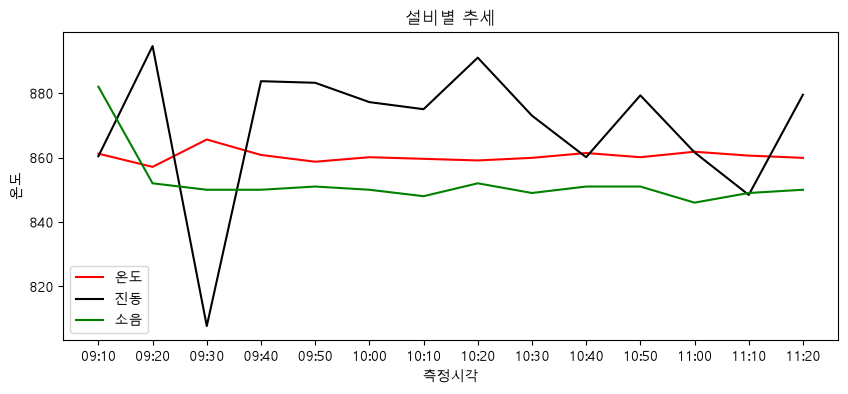

In [9]:
df_c = df[df['배치'] == '로트C']

plt.figure(figsize=(10, 4)) 
plt.title('설비별 추세')

plt.plot(df_c['측정시각'], df_c['온도'], label = '온도', color = "red")
plt.plot(df_c['측정시각'], df_c['OP값'] + 800, label = '진동', color = "black") # 진동
plt.plot(df_c['측정시각'], df_c['CP값'] * 1000 + 400, label = '소음', color = "green") # 소음

plt.legend()

plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')

plt.show()